# MP1 — Offline replay

This notebook loads **`mp1_data_snapshot.json`** (built by `build_mp1_data_snapshot.py`) so you can rerun plots and tables **without** Last.fm API calls or `LASTFM_API_KEY`.

Regenerate the snapshot after you change API logic or want fresher data:

`python3 build_mp1_data_snapshot.py`

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import pandas as pd

# Look for the snapshot next to this notebook (cwd) or under the known assignment path
_SNAPSHOT = None
for p in (
    Path.cwd() / "mp1_data_snapshot.json",
    Path.cwd() / "Week 5" / "A5 Pandas Assignment" / "mp1_data_snapshot.json",
):
    if p.is_file():
        _SNAPSHOT = p.resolve()
        break

if _SNAPSHOT is None:
    raise FileNotFoundError(
        "mp1_data_snapshot.json not found. Place it next to this notebook, cd to that folder, "
        "or run: python3 build_mp1_data_snapshot.py"
    )

with open(_SNAPSHOT, encoding="utf-8") as f:
    snap = json.load(f)


def df_from_snapshot(key: str) -> pd.DataFrame:
    block = snap[key]
    return pd.DataFrame(block["records"], columns=block["columns"])


print("Loaded:", _SNAPSHOT)
if "_snapshot_meta" in snap:
    print("Snapshot UTC:", snap["_snapshot_meta"].get("generated_at_utc", "?"))

Loaded: /Users/genalee/Code/hcde530/Week 5/A5 Pandas Assignment/mp1_data_snapshot.json
Snapshot UTC: 2026-05-07T04:23:15.088383+00:00


In [2]:
# Core tables (same names as mp1.ipynb)
df = df_from_snapshot("df")
names_by_country = df_from_snapshot("names_by_country")
pairwise_df = df_from_snapshot("pairwise_df")
unique_df = df_from_snapshot("unique_df")
rq1_overlap_summary = df_from_snapshot("rq1_overlap_summary")
tags_df = df_from_snapshot("tags_df")
chart100_df = df_from_snapshot("chart100_df")
rq3_artists_df = df_from_snapshot("rq3_artists_df")
rq3_genre_summary = df_from_snapshot("rq3_genre_summary")

print("Shapes:", {k: len(df_from_snapshot(k)) for k in ("df", "tags_df", "chart100_df", "rq3_artists_df", "rq3_genre_summary")})

Shapes: {'df': 60, 'tags_df': 50, 'chart100_df': 99, 'rq3_artists_df': 98, 'rq3_genre_summary': 5}


## Research Question 1 — Top artists by country & overlap

Data source in snapshot: **`geo.getTopArtists`** for United States, Brazil, South Korea.

In [3]:
TABLE_COLS = ["country_label", "name", "listeners"]
TABLE_COLS = [c for c in TABLE_COLS if c in df.columns]
df[TABLE_COLS]

,country_label,name,listeners
0,United States,Kanye West,242926
1,United States,Drake,238213
2,United States,Kendrick Lamar,228488
3,United States,"Tyler, The Creator",228055
4,United States,PinkPantheress,214472
5,United States,Radiohead,206407
6,United States,The Weeknd,198587
7,United States,Rihanna,198126
8,United States,Tame Impala,191412
9,United States,Michael Jackson,186669


In [4]:
try:
    from IPython.display import display
except ImportError:
    display = print

print("Artist names (columns = country), top 10 ranks")
display(names_by_country)

Artist names (columns = country), top 10 ranks


,rank,Brazil,South Korea,United States
0,1,Lady Gaga,Justin Bieber,Kanye West
1,2,Sabrina Carpenter,Kanye West,Drake
2,3,Ariana Grande,ILLIT,Kendrick Lamar
3,4,Taylor Swift,The Weeknd,"Tyler, The Creator"
4,5,Marina Sena,Kendrick Lamar,PinkPantheress
5,6,Anitta,BTS,Radiohead
6,7,Lana Del Rey,LE SSERAFIM,The Weeknd
7,8,Michael Jackson,Ariana Grande,Rihanna
8,9,The Weeknd,NewJeans,Tame Impala
9,10,Rihanna,Drake,Michael Jackson


In [5]:
print("Pairwise overlap (same artist name on both charts):")
display(pairwise_df)

_row = rq1_overlap_summary.iloc[0]
print(
    f"\nArtists on the top chart for ALL three countries ({int(_row['count'])} total):"
)
print(_row["names_csv"] if _row["names_csv"] else "(none)")

print("\nArtists that appear only on one country's chart:")
display(unique_df)

Pairwise overlap (same artist name on both charts):


,profile_country_a,profile_country_b,overlap_artists,jaccard_similarity
0,Brazil,South Korea,10,0.3333
1,Brazil,United States,12,0.4286
2,South Korea,United States,15,0.6000



Artists on the top chart for ALL three countries (10 total):
Ariana Grande, Charli xcx, Justin Bieber, Lady Gaga, PinkPantheress, Sabrina Carpenter, Tame Impala, Taylor Swift, The Weeknd, Tyler, The Creator

Artists that appear only on one country's chart:


,profile_country,artists_only_on_this_chart,examples
0,Brazil,8,"Anitta, Arctic Monkeys, Beyoncé, Billie Eilish..."
1,South Korea,5,"BTS, CORTIS, ILLIT, LE SSERAFIM, NewJeans"
2,United States,3,"Childish Gambino, Malcolm Todd, Paramore"


## Research Question 2 — Tags / reach (`chart.getTopTags`)

Loaded from snapshot as **`tags_df`**.

In [6]:
out_cols = [c for c in ("name", "reach", "taggings") if c in tags_df.columns]
tags_df[out_cols].head(20)

,name,reach,taggings
0,rock,403030,4070908
1,alternative,267280,2131501
2,electronic,262384,2501487
3,indie,260558,2065995
4,pop,233904,2084521
5,alternative rock,170338,1232172
6,female vocalists,169184,1634893
7,metal,159073,1306379
8,folk,151407,959834
9,ambient,150311,1127211


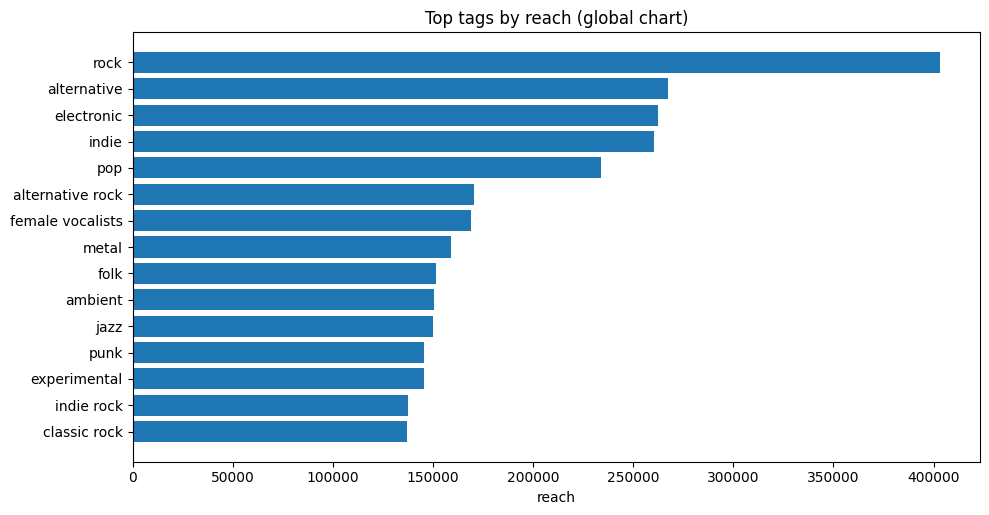

In [7]:
import matplotlib.pyplot as plt

top_n = 15
plot_df = tags_df.head(top_n).iloc[::-1]

fig, ax = plt.subplots(figsize=(10, max(5, top_n * 0.35)))
ax.barh(plot_df["name"].astype(str), plot_df["reach"])
ax.set_xlabel("reach")
ax.set_title("Top tags by reach (global chart)")
plt.tight_layout()
plt.show()

## Research Question 3 — Play per listener by primary tag

Per-artist enrichment is stored as **`rq3_artists_df`**; aggregated rankings as **`rq3_genre_summary`**.

In [8]:
display(
    rq3_genre_summary.head(20)[
        [
            "genre_tag",
            "median_play_per_listener",
            "weighted_play_per_listener",
            "n_artists",
        ]
    ]
)

,genre_tag,median_play_per_listener,weighted_play_per_listener,n_artists
0,rnb,138.946314,150.845459,6
1,Hip-Hop,122.964012,140.309627,11
2,pop,107.570439,105.701841,23
3,rock,103.920436,109.857245,5
4,indie,80.909842,125.877521,6


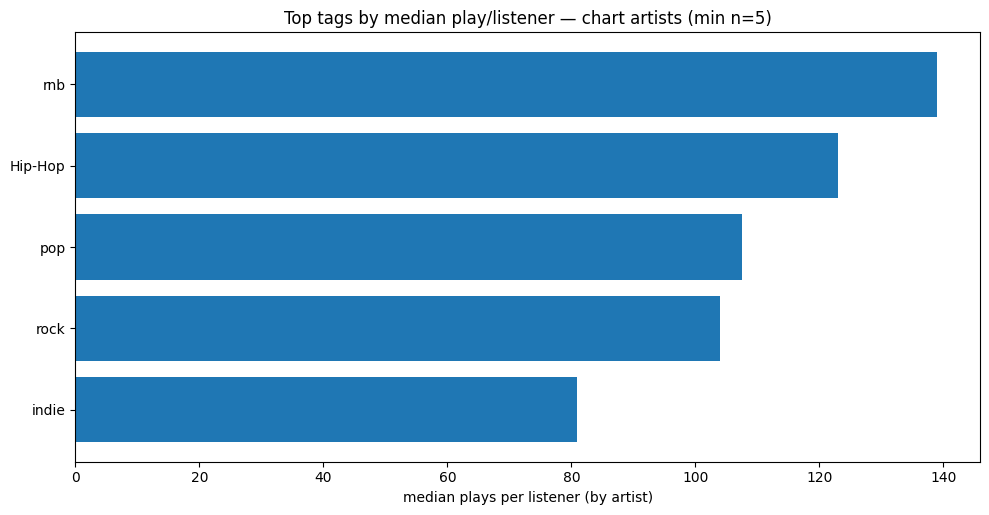

In [9]:
MIN_ARTISTS_PER_TAG = 5
RQ3_TOP_K = 15

if rq3_genre_summary.empty:
    print("rq3_genre_summary is empty.")
else:
    _plot = rq3_genre_summary.head(RQ3_TOP_K).iloc[::-1]
    fig, ax = plt.subplots(figsize=(10, max(5, RQ3_TOP_K * 0.35)))
    ax.barh(_plot["genre_tag"].astype(str), _plot["median_play_per_listener"])
    ax.set_xlabel("median plays per listener (by artist)")
    ax.set_title(
        f"Top tags by median play/listener — chart artists (min n={MIN_ARTISTS_PER_TAG})"
    )
    plt.tight_layout()
    plt.show()

In [10]:
# Optional: inspect chart + per-artist RQ3 inputs
try:
    from IPython.display import display
except ImportError:
    display = print

if "mbid" in chart100_df.columns:
    display(chart100_df[["name", "mbid"]].head(10))
else:
    display(chart100_df.head(10))
display(rq3_artists_df.head(10))

,name,mbid
0,The Weeknd,c8b03190-306c-4120-bb0b-6f2ebfc06ea9
1,Kanye West,NaN
2,Lady Gaga,650e7db6-b795-4eb5-a702-5ea2fc46c848
3,PinkPantheress,7441014f-f8f5-494f-81db-ff166fbc078d
4,Justin Bieber,e0140a67-e4d1-4f13-8a01-364355bee46e
5,Tame Impala,63aa26c3-d59b-4da4-84ac-716b54f1ef4d
6,Rihanna,73e5e69d-3554-40d8-8516-00cb38737a1c
7,Drake,9fff2f8a-21e6-47de-a2b8-7f449929d43f
8,Michael Jackson,f27ec8db-af05-4f36-916e-3d57f91ecf5e
9,Kendrick Lamar,381086ea-f511-4aba-bdf9-71c753dc5077


,name,mbid,playcount,listeners,play_per_listener,genre_tag
0,The Weeknd,c8b03190-306c-4120-bb0b-6f2ebfc06ea9,1.127371e+09,5331220.0,211.465833,rnb
1,Kanye West,NaN,1.547351e+09,7964268.0,194.286616,Hip-Hop
2,Lady Gaga,650e7db6-b795-4eb5-a702-5ea2fc46c848,1.037051e+09,7736367.0,134.048899,pop
3,PinkPantheress,7441014f-f8f5-494f-81db-ff166fbc078d,3.332845e+08,3098291.0,107.570439,pop
4,Justin Bieber,e0140a67-e4d1-4f13-8a01-364355bee46e,3.378581e+08,4852246.0,69.629219,pop
5,Tame Impala,63aa26c3-d59b-4da4-84ac-716b54f1ef4d,4.225220e+08,4405189.0,95.914609,Psychedelic Rock
6,Rihanna,73e5e69d-3554-40d8-8516-00cb38737a1c,6.047458e+08,8311872.0,72.756867,pop
7,Drake,9fff2f8a-21e6-47de-a2b8-7f449929d43f,1.171191e+09,6732738.0,173.954627,Hip-Hop
8,Michael Jackson,f27ec8db-af05-4f36-916e-3d57f91ecf5e,3.632706e+08,6885537.0,52.758493,pop
9,Kendrick Lamar,381086ea-f511-4aba-bdf9-71c753dc5077,1.034450e+09,5109210.0,202.467698,Hip-Hop
